### Importing  Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

In [15]:
# Load the dataset
df = pd.read_csv("heart_disease_uci.csv")
 
# Quick look at the data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (920, 16)

First 5 rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [16]:
# Basic info and statistics to understand the dataset
 
print(df.info())

print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB
None
               id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.000000  890

In [40]:
# Check for missing values — clean data = better model
 
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [41]:
# Drop non-feature columns, split into features and target

df["target"] = df["num"].apply(lambda x: 1 if x > 0 else 0)
 
print("Target distribution:")
print(df["target"].value_counts())

Target distribution:
target
1    509
0    411
Name: count, dtype: int64


C:\Users\Computer Arena\AppData\Local\Temp\ipykernel_6624\1906654954.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["target"], palette="Set2")


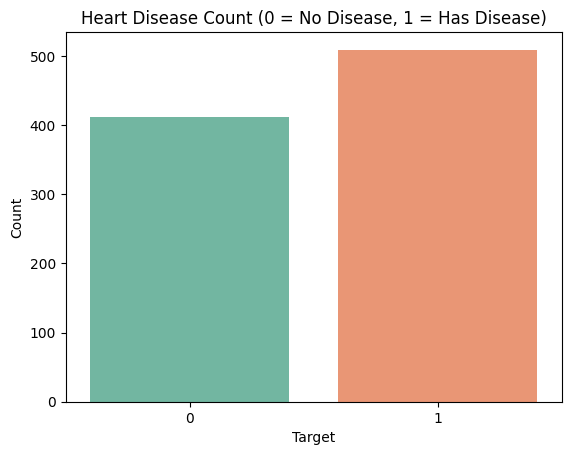

In [42]:
# EDA — how many people have heart disease vs not?
 
sns.countplot(x=df["target"], palette="Set2")
plt.title("Heart Disease Count (0 = No Disease, 1 = Has Disease)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()
 

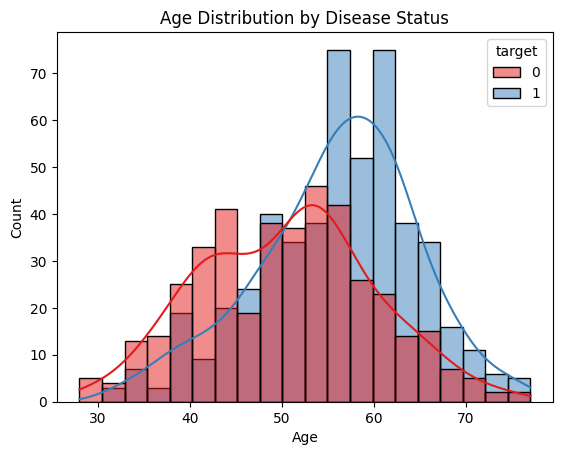

In [43]:
# Age distribution split by disease status
 
sns.histplot(data=df, x="age", hue="target", bins=20, kde=True, palette="Set1")
plt.title("Age Distribution by Disease Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

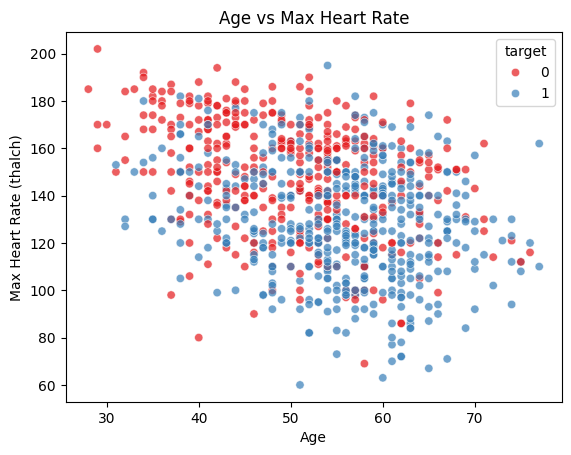

In [44]:
# Max heart rate vs age — colored by disease status
 
sns.scatterplot(x="age", y="thalch", hue="target", data=df, palette="Set1", alpha=0.7)
plt.title("Age vs Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate (thalch)")
plt.show()

In [45]:
# Prepare features
 
# Drop columns not useful for prediction
X = df.drop(["id", "dataset", "num", "target"], axis=1)
y = df["target"]
 
# Convert boolean columns (True/False) to plain integers (1/0)
X["fbs"] = X["fbs"].map({True: 1, False: 0})
X["exang"] = X["exang"].map({True: 1, False: 0})
 
X = pd.get_dummies(X, columns=["sex", "cp", "restecg", "slope", "thal"], drop_first=True)
 
# Fill missing values with column mean
X = X.fillna(X.mean(numeric_only=True))
 
print("Final feature columns:", X.columns.tolist())
print("Shape after preprocessing:", X.shape)

Final feature columns: ['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']
Shape after preprocessing: (920, 18)


In [46]:
# Split into train and test sets
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 736
Testing samples: 184


In [49]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit on train only
X_test = scaler.transform(X_test)        # just transform test (no fitting)

 
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
 
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability scores needed for ROC
 
print("Model trained successfully!")

Model trained successfully!


Accuracy: 80.43%


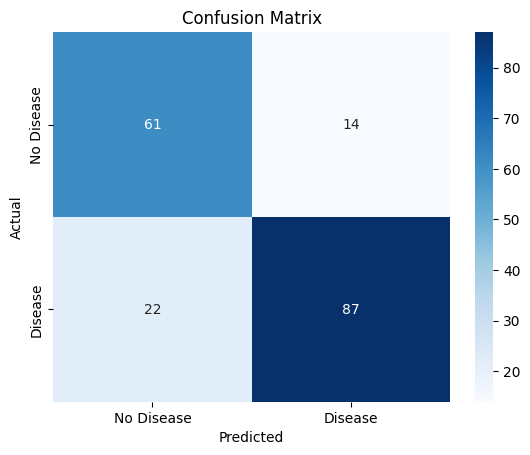

In [50]:
# Accuracy and confusion matrix
 
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
 
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

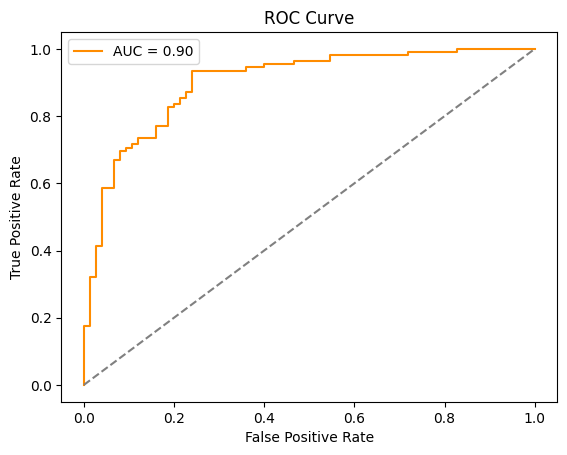

In [58]:
# AUC closer to 1.0 = better model
 
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
 
plt.plot(fpr, tpr, color="darkorange", label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

C:\Users\Computer Arena\AppData\Local\Temp\ipykernel_6624\3731563253.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_df, palette="viridis")


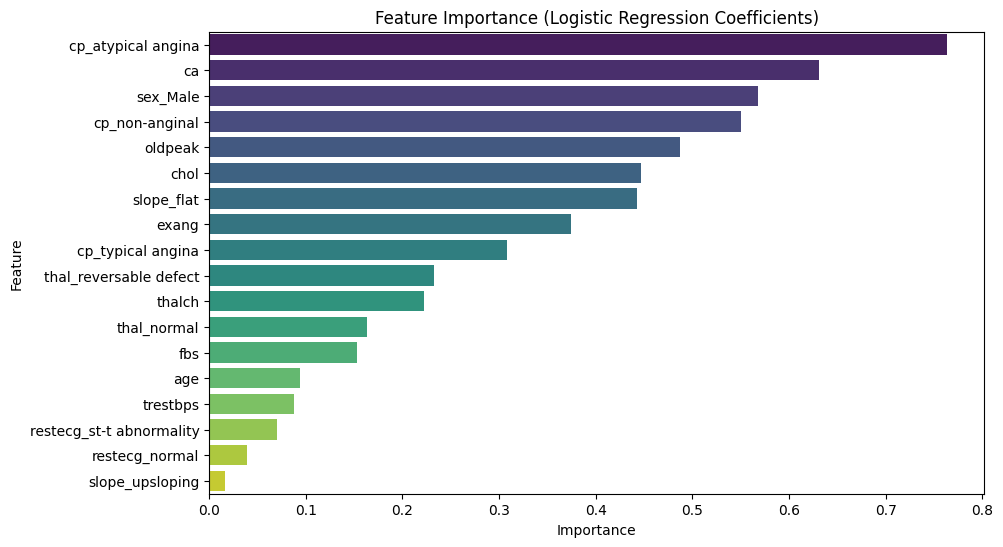

In [59]:
# Feature importance — which health indicators drive the prediction most?
 
feature_names = X.columns.tolist()
coefficients = model.coef_[0]
 
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(coefficients)  # absolute value = strength of influence
}).sort_values("Importance", ascending=False)
 
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_df, palette="viridis")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()

In [60]:
# Final summary
 
print("=" * 40)
print("FINAL RESULTS SUMMARY")
print("=" * 40)
print(f"Model        : Logistic Regression")
print(f"Accuracy     : {accuracy * 100:.2f}%")
print(f"ROC-AUC Score: {auc_score:.2f}")
print("\nTop 3 most important features:")
print(feat_df[["Feature", "Importance"]].head(3).to_string(index=False))

FINAL RESULTS SUMMARY
Model        : Logistic Regression
Accuracy     : 80.43%
ROC-AUC Score: 0.90

Top 3 most important features:
           Feature  Importance
cp_atypical angina    0.763613
                ca    0.631084
          sex_Male    0.567773
